In [84]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [85]:
df = pd.read_csv("../data/network_incidents.csv")

df.head()

,Timestamp,Device,Location,Incident_Type,Severity,CPU_Usage,Memory_Usage,Packet_Loss_Percentage,Resource_Stress,Network_Stress
0,2026-05-11 01:19:45.213835,SW1-Access,Pune,Route Flapping,Major,41,46,10.01,87,100.1
1,2026-05-11 01:24:45.213835,SW2-Distribution,Mumbai,High CPU Usage,Warning,53,60,0.38,113,3.8
2,2026-05-11 01:29:45.213835,R1-Core,Mumbai,Route Flapping,Warning,73,52,3.00,125,30.0
3,2026-05-11 01:34:45.213835,SW1-Access,Mumbai,BGP Neighbor Down,Major,85,82,4.91,167,49.1
4,2026-05-11 01:39:45.213835,SW1-Access,Pune,Route Flapping,Major,58,85,14.43,143,144.3


In [86]:
df["Critical_Incident"] = df["Severity"].apply(
    lambda x: 1 if x == "Critical" else 0
)

df.head()

,Timestamp,Device,Location,Incident_Type,Severity,CPU_Usage,Memory_Usage,Packet_Loss_Percentage,Resource_Stress,Network_Stress,Critical_Incident
0,2026-05-11 01:19:45.213835,SW1-Access,Pune,Route Flapping,Major,41,46,10.01,87,100.1,0
1,2026-05-11 01:24:45.213835,SW2-Distribution,Mumbai,High CPU Usage,Warning,53,60,0.38,113,3.8,0
2,2026-05-11 01:29:45.213835,R1-Core,Mumbai,Route Flapping,Warning,73,52,3.00,125,30.0,0
3,2026-05-11 01:34:45.213835,SW1-Access,Mumbai,BGP Neighbor Down,Major,85,82,4.91,167,49.1,0
4,2026-05-11 01:39:45.213835,SW1-Access,Pune,Route Flapping,Major,58,85,14.43,143,144.3,0


In [87]:
encoder = LabelEncoder()

df["Device"] = encoder.fit_transform(df["Device"])
df["Location"] = encoder.fit_transform(df["Location"])
df["Incident_Type"] = encoder.fit_transform(df["Incident_Type"])

In [88]:
X = df[[
    "Device",
    "Location",
    "Incident_Type",
    "CPU_Usage",
    "Memory_Usage",
    "Packet_Loss_Percentage",
    "Resource_Stress",
    "Network_Stress"
]]

y = df["Critical_Incident"]

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Accuracy: 0.97

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        81
           1       1.00      0.84      0.91        19

    accuracy                           0.97       100
   macro avg       0.98      0.92      0.95       100
weighted avg       0.97      0.97      0.97       100



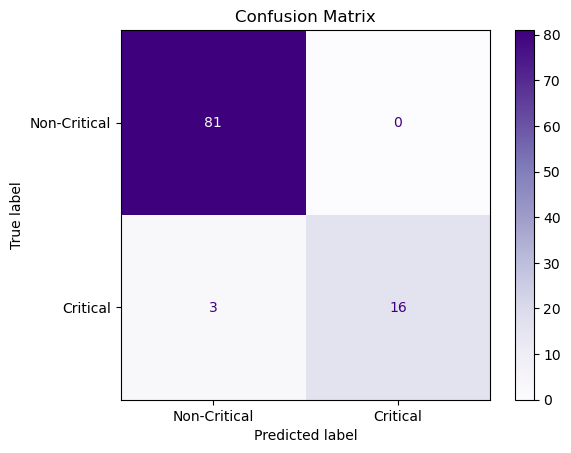

Model saved successfully.


In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Critical", "Critical"]
)

disp.plot(cmap="Purples")

plt.title("Confusion Matrix")

plt.show()

# Save model
joblib.dump(model, "../models/decision_tree_model.pkl")

print("Model saved successfully.")